Name: **your name here**

In [1]:
# Show all output of one executed cell:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import matplotlib.pyplot as plt

# Human metabolic model

The human metabolic model is probably one if not the biggest GSMM/GEM out there.

## Task 1 Model details

- Load the model
- Check its size
- Derive summaries (with <code>df.groupby</code>) from pandas dataframes with 
    - the number of metabolites in different compartments
    - the number of reactions in different subsystems 



human model recon3d
model stats
model subsystems
use different diets for running it
analyse subsystem activity changes for different diets
run flux samplings
  use flux sampling to identify correlating reactions
    analyse for different diets

In [2]:
## your code ##
## load packages
import cobra
from cobra.io import read_sbml_model
from cobra.io.mat import load_matlab_model
#cobra.io.mat.load_matlab_model
from pathlib import Path
import pandas as pd 
PATH = Path(".") / ".." / "day4" 
PATH = PATH.resolve()
PATH

FN= "Recon3D_301.mat"
#FN2= "Recon3DModel_301.mat"
mHsa = load_matlab_model(str((PATH / FN).resolve()) )
#mHsa2 = load_matlab_model(str((PATH / FN2).resolve()) )
# cant see that the models are different
## --- ##

PosixPath('/home/schaeuble/Documents/teaching/2402_Norge_workshop/material/day4')

No defined compartments in model Recon3D. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, g, i, l, m, n, r, x


Name,Recon3D
Memory address,7f75033fbe10
Number of metabolites,8399
Number of reactions,13543
Number of genes,3697
Number of groups,111
Objective expression,1.0*biomass_reaction - 1.0*biomass_reaction_reverse_32a6c
Compartments,"c, l, m, r, e, x, n, g, i"


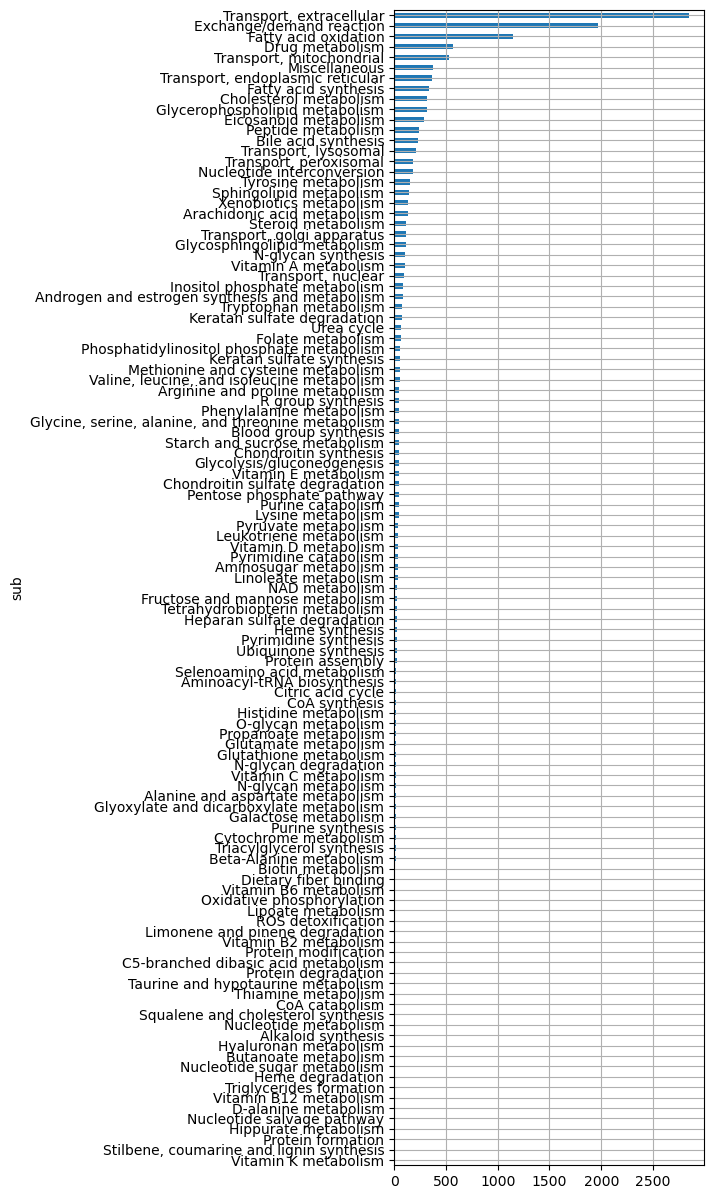

In [9]:
## your code ##

## pandas for reaction information (ids and subsystem)
rxnInfo = pd.DataFrame({
    'id':[(r.id) for r in mHsa.reactions],
    'sub':[(r.subsystem) for r in mHsa.reactions]
})
#rxnInfo.head()
## groupby and plot
rxnInfoSummary = rxnInfo.groupby('sub').size().sort_values()
rxnInfoSummary
rxnInfoSummary.plot(kind='barh', figsize = (4,15), grid=1);

## --- ##

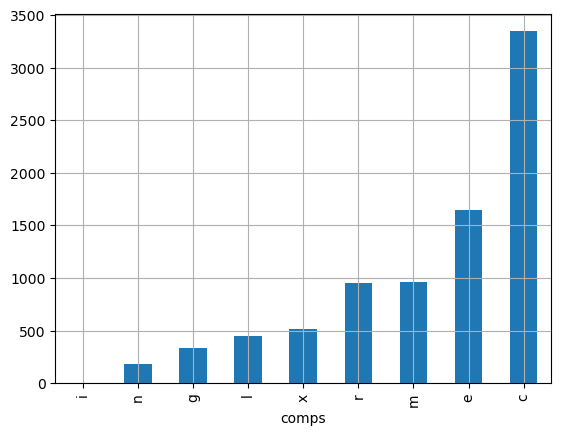

In [12]:
## your code ##

## pandas for metabolite information (ids and compartment)
metsInfo = pd.DataFrame({
    'id':[(r.id) for r in mHsa.metabolites],
    'comps':[(r.compartment) for r in mHsa.metabolites]
})
#metsInfo.head()
## groupby and plot
metsInfoSummary = metsInfo.groupby('comps').size().sort_values()
metsInfoSummary
pl2 = metsInfoSummary.plot(kind='bar', grid=1);

## --- ##

**Note**  
compartment codes  
- cytosol [c]
- extracellular space [e]
- Golgi apparatus [g]
- lysosome [l]
- mitochondria [m]
- nucleus [n]
- endoplasmic reticulum [r]
- peroxisome [x]
- additional inner mitochondrial compartment [i]

## Task 2 Objective function

Recon3D has several objective biomass functions.
- Find them by searching for the term "biomass" in the reaction ids.
- Optimise the model for all meaningful obj biomass functions


In [19]:
## your code ##
[print("%s" % r.id) for r in mHsa.reactions if 'biomass' in r.id]

mHsa.objective = "biomass_reaction"
mHsa.slim_optimize()
mHsa.objective = "biomass_maintenance"
mHsa.slim_optimize()
mHsa.objective = "biomass_maintenance_noTrTr"
mHsa.slim_optimize()

## --- ##

biomass_reaction
biomass_maintenance
biomass_maintenance_noTrTr
HMR_biomass_Renalcancer
DM_HMR_biomass_renalcancer
biomass_components


[None, None, None, None, None, None]

1000.0

1000.0

1000.0

**Note on biomass**
https://static-content.springer.com/esm/art%3A10.1038%2Fnbt.4072/MediaObjects/41587_2018_BFnbt4072_MOESM9_ESM.pdf

Recon 3 contains three different versions of the biomass function reaction. These are (i) biomass_reaction, (ii)
biomass_maintenance, and (iii) biomass_maintenance_noTrTr. The biomass_reaction is the general biomass reaction as
in Recon 3, biomass_ maintenance is same as biomass_reaction except for the nuclear deoxynucleotides, and
biomass_maintenance_noTrTr is devoid of amino acids, nuclear deoxynucleotides, and cellular deoxynucleotides except
for adenosine-triphosphate. The biomass_reaction can be used only for tissues known to possess re-generative capacity,
i.e., liver82, heart83, and kidney84. For others, biomass_ maintenance was added, indicating the maintenance of cellular
metabolic profiles, i.e., the model’s capability to synthesize all the biomass components excepting the nuclear
deoxynucleotides. The biomass_maintenance_noTrTr reaction can be used to model specific conditions, e.g., fasting
condition. Such a modification was done as the human body has no store for amino acids46. Amino acids if stored
intracellularly, increase the osmotic pressure, necessitating their rapid catabolism46. Such catabolic processes mainly
occur for those that are not required for protein synthesis.

## Task 3 Adapt specific diets

- As on the last day load and adapt specific diets
    - mediterranean diet
    - high protein diet 

In [39]:
## your code ##
## load diets; class Path from pathlib may help
from pathlib import Path
PATH = Path(".") / ".." / "day4" 
PATH = PATH.resolve()
PATH
diet_medi = pd.read_csv(str((PATH / "diet_mediterranean.tsv").resolve()), sep = '\t' )
diet_prot = pd.read_csv(str((PATH / "diet_highProtein.tsv").resolve()), sep = '\t' )

# diet_prot
## put diet information in dictionaries if EX reactions are also in the model (same approach as during last workshop day)
diet_medi_dict = diet_medi.set_index('Reaction')['Flux Value'].to_dict()
diet_medi_dict = {key: diet_medi_dict[key] for key in mHsa.exchanges.list_attr('id') if key in diet_medi_dict}
diet_prot_dict = diet_prot.set_index('Reaction')['Flux Value'].to_dict()
diet_prot_dict = {key: diet_prot_dict[key] for key in mHsa.exchanges.list_attr('id') if key in diet_prot_dict}

diet_medi_dict
diet_prot_dict

## --- ##

PosixPath('/home/schaeuble/Documents/teaching/2402_Norge_workshop/material/day4')

{'EX_10fthf[e]': 0.000264396082163,
 'EX_5mthf[e]': 0.0002718793127855,
 'EX_adrn[e]': 0.0253384416436082,
 'EX_arach[e]': 1.87694307794782,
 'EX_arachd[e]': 0.268570142447626,
 'EX_ascb_L[e]': 0.78205214594652,
 'EX_avite1[e]': 0.0545731764653438,
 'EX_caro[e]': 0.0059790721299615,
 'EX_chsterol[e]': 0.687954460518268,
 'EX_clpnd[e]': 0.108954215556962,
 'EX_crvnc[e]': 3.86099560798008,
 'EX_hdca[e]': 56.4191137520305,
 'EX_hdcea[e]': 5.64971706821184,
 'EX_hpdca[e]': 0.88683048380973,
 'EX_i[e]': 0.003914204125355,
 'EX_lgnc[e]': 0.909993993941715,
 'EX_lnlc[e]': 73.5942742115858,
 'EX_lnlnca[e]': 7.87609621020994,
 'EX_ncam[e]': 0.211750949440162,
 'EX_ocdca[e]': 13.6440877371906,
 'EX_ocdcea[e]': 128.160754142604,
 'EX_octa[e]': 1.80037499083472,
 'EX_phyQ[e]': 0.0003015782045402,
 'EX_ptdca[e]': 1.18352240527347,
 'EX_retinol[e]': 0.558558583718855,
 'EX_strch1[e]': 41.0264143574528,
 'EX_strdnc[e]': 0.614547696526362,
 'EX_thf[e]': 0.000281097792962,
 'EX_ttdca[e]': 12.6565448203

{'EX_10fthf[e]': 0.000251925869611,
 'EX_5mthf[e]': 0.0002590561544725,
 'EX_adrn[e]': 0.0265450341028276,
 'EX_arach[e]': 0.672744344308999,
 'EX_arachd[e]': 0.589371410757767,
 'EX_ascb_L[e]': 1.12239758514632,
 'EX_avite1[e]': 0.0395861586357844,
 'EX_caro[e]': 0.0095180867863251,
 'EX_chsterol[e]': 1.59535604876201,
 'EX_clpnd[e]': 0.279517639353656,
 'EX_crvnc[e]': 3.2314920928068,
 'EX_hdca[e]': 37.6624848629354,
 'EX_hdcea[e]': 3.96767486068485,
 'EX_hpdca[e]': 0.410384100218711,
 'EX_i[e]': 0.003562207068041,
 'EX_lgnc[e]': 0.0680985820479788,
 'EX_lnlc[e]': 29.2730932677253,
 'EX_lnlnca[e]': 1.65812551793894,
 'EX_ncam[e]': 0.245118510111804,
 'EX_ocdca[e]': 12.3352158417155,
 'EX_ocdcea[e]': 99.5013028799794,
 'EX_octa[e]': 0.64226782166637,
 'EX_phyQ[e]': 0.0005128626698679,
 'EX_ptdca[e]': 0.364452321061057,
 'EX_retinol[e]': 2.07713973320449,
 'EX_strch1[e]': 27.0864409377219,
 'EX_strdnc[e]': 0.0813345252714358,
 'EX_thf[e]': 0.0002678398460307,
 'EX_ttdca[e]': 4.25546372

In [31]:
## your code ##
## make model copies for each diet
## note, this takes a while
m_medi = mHsa.copy()
m_prot = mHsa.copy()
## copy the "standard" medium to variables
m_medi_media = m_medi.medium
m_prot_media = m_prot.medium
## --- ##

In [38]:
## your code ##

objs = ('biomass_reaction','biomass_maintenance','biomass_maintenance_noTrTr')

## adapt media and optimise on the three different biomass objectives
## use once strictly only the media components at the given flux and once by merging them into the existing reactions 

## Mediterranean diet
print("Merged medi medium:")
m_medi.medium = m_medi_media
m_medi.medium = {key: diet_medi_dict[key] if key in diet_medi_dict else value for key, value in mHsa.medium.items()}
for o in objs:
    print("objective:", o)
    m_medi.objective = o
    m_medi.slim_optimize()
print("Precise medi medium:")
m_medi.medium = diet_medi_dict
for o in objs:
    print("objective:", o)
    m_medi.objective = o
    m_medi.slim_optimize()

## high protein diet
print("Merged protein medium:")
m_prot.medium = m_prot_media
m_prot.medium = {key: diet_prot_dict[key] if key in diet_prot_dict else value for key, value in mHsa.medium.items()}
for o in objs:
    print("objective:", o)
    m_prot.objective = o
    m_prot.slim_optimize()
print("Precise protein medium:")
m_prot.medium = diet_prot_dict
for o in objs:
    print("objective:", o)
    m_prot.objective = o
    m_prot.slim_optimize()

## --- ##

Merged medi medium:
objective: biomass_reaction


1000.0

objective: biomass_maintenance


1000.0

objective: biomass_maintenance_noTrTr


...

535.3061397193711

objective: biomass_maintenance


537.857371730494

objective: biomass_maintenance_noTrTr


547.063413545358

What do you make of these results?  
How does this compare to the bacterial models you analysed the last day?

>
> #### your answer
>

---

## Task 4 Compare subsystem activity

- Optimise the generic biomass function for both diets
- Run FVA for the subsystems
    - glycolysis
    - NAD metabolism
    - trytohan metabolism
    - arginine metabolims

### Task 4.1 Identify reactions of interest

In [74]:
## your code ##
## find out correct subsystem name by e.g. checking keywords in your reaction summary table from above
[print(s, rxnInfoSummary[s]) for s in rxnInfoSummary.keys() if 'Glycol' in s];
[print(s, rxnInfoSummary[s]) for s in rxnInfoSummary.keys() if 'NAD' in s];
[print(s, rxnInfoSummary[s]) for s in rxnInfoSummary.keys() if 'Tryptophan' in s];
[print(s, rxnInfoSummary[s]) for s in rxnInfoSummary.keys() if 'Arg' in s];
## --- ##

Glycolysis/gluconeogenesis 45
NAD metabolism 32
Tryptophan metabolism 77
Arginine and proline metabolism 51


In [95]:
## your code ##
subNames = ['NAD metabolism', 'Glycolysis/gluconeogenesis', 'Tryptophan metabolism', 'Arginine and proline metabolism']
## get all rxn IDs and subsystem association over all models associated to these pathways
rxnIDs = set()
subs = dict()
rxnIDs.update({ (r.id) for r in mHsa.reactions if r.subsystem in subNames})
subs.update({ r.id: (r.subsystem) for r in mHsa.reactions if r.subsystem in subNames if r.id not in subs})
## the length of your reaction set should be 205
len(rxnIDs)
len(subs)
## --- ##

205

205

### Task 4.2 Adapt diets to models

In [90]:
## your code ##
from cobra.medium import minimal_medium
## change to biomass_reaction objective function
m_medi.objective = 'biomass_reaction'
m_medi.medium = diet_medi_dict
m_medi.slim_optimize()
m_prot.objective = 'biomass_reaction'
m_prot.medium = diet_prot_dict
m_prot.slim_optimize()


## --- ##

535.3061397193721

535.3061397193708

### Task 4.3 Run FVA

*Takes long!*

Run on Tryptophan only if your machine power is low.

In [97]:
## your code ##
## load fva
from cobra.flux_analysis import flux_variability_analysis as fva 

## start creating a meaningful pandas df holding your rxnIDs (use as index) and subsystem information
rxnIDs = [r.id for r in mHsa.reactions if r.subsystem in subNames]

fluxes = pd.DataFrame(data={ 'sub' : [r.subsystem for r in mHsa.reactions if r.id in rxnIDs]}, 
                      index=rxnIDs
                     )

## FVA for medi medium
m_medi.medium = diet_medi_dict

m_medi.slim_optimize()
tmp = fva(m_medi, reaction_list=rxnIDs, pfba_factor=1.1, fraction_of_optimum=0.9)
fluxes['medi_lb'] = tmp['minimum']
fluxes['medi_ub'] = tmp['maximum']
## FVA for high protein medium
m_prot.medium = diet_prot_dict

m_prot.slim_optimize()
tmp = fva(m_prot, reaction_list=rxnIDs, pfba_factor=1.1, fraction_of_optimum=0.9)
fluxes['prot_lb'] = tmp['minimum']
fluxes['prot_ub'] = tmp['maximum']
## --- ##

535.3061397193721

535.3061397193712

### Task 4.1 Vizualise the fraction of changes

Change of flux per reaction by at least 5%.

,Change,total
sub,,
Arginine and proline metabolism,0,51
Glycolysis/gluconeogenesis,1,45
NAD metabolism,1,32
Tryptophan metabolism,3,77


<Axes: xlabel='sub'>

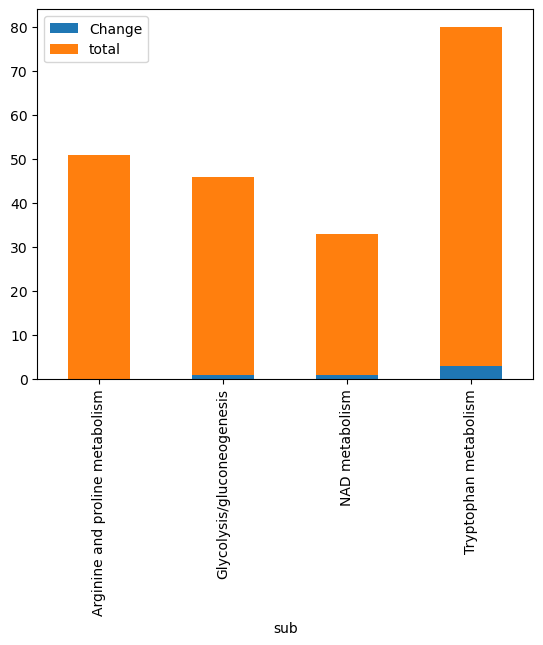

In [104]:
## your code ##
# visualize change
OFFSET = .05

fluxes['Change'] = ( 
    ((fluxes['medi_lb'] / fluxes['bad_lb']) > 1+OFFSET) |
    ((fluxes['medi_lb'] / fluxes['bad_lb']) < 1-OFFSET) |
    ((fluxes['medi_ub'] / fluxes['bad_ub']) < 1-OFFSET) |
    ((fluxes['medi_ub'] / fluxes['bad_ub']) < 1-OFFSET)
    ).astype(int)


category_counts = fluxes.groupby('sub')['Change'].sum()

fluxes_summary = pd.DataFrame(data=category_counts)
#fluxes['sub'].value_counts() 
fluxes_summary['total'] = fluxes['sub'].value_counts() 
fluxes_summary
fluxes_summary.plot(kind='bar', stacked=True)

## --- ##

---

# Lessons learned

By now you have a good idea about running basic CBM analysis of genome-scale metabolic models.
You learned
- how to use cobrapy to run basic analysis tasks
- learned/refreshed how to use Python and pandas data structures to manage larger amounts of data  
- experienced that runtime depends on algorithm and model size
- medium composition can have substantial impact on model fluxes
    - this is equivalent to adapting metabolomics data from e.g. stool samples (for gut microbe analysis) or supernatants 

There is more
- various tools to integrate more omics data, e.g. transcriptomics
    - requires a better solver (academic licenses available for IBM or GUROBI)
- combining bacterial models to study interactions
- spatial modeling using one GEM per grid patch
- tools/algorithms streamlined to optimize target metabolite output (optKnock, optForce, ...)
- tools to study metabolic disease and minimal adjustments to revert back to a healthy state (MTA)
- ...

**Thank you very much for taking part in this course!**

Your feedback is appreciated and helpful to improve the course and students experience. 